In [1]:
# environment: scenv
# snapatac2 version: 2.8.0

import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import snapatac2 as snap
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
import pyranges as pr
import os
import warnings
import requests
from importlib import reload
from umap import UMAP
from sklearn.decomposition import PCA
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cross_decomposition import CCA

from tqdm import tqdm
tqdm.pandas()

import sys
sys.path.append('/data1/normantm/multiome_collab')
from perturbseq import *
import multiome as mo

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

### 2a ab / ba on-target activation

In [ ]:
adata = sc.read('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex_counts.h5ad')
sc.pp.normalize_total(adata, target_sum=1e6)
adata.obs['feature_call'] = adata.obs.progress_apply(lambda df: f"{df.target_a.split('_')[0]}_{df.target_b.split('_')[0]}" if not pd.isna(df.target_a) else f"{df.threshold_feature_a.split('_')[0]}_{df.threshold_feature_b.split('_')[0]}", axis=1)

In [3]:
adata.obs.total_counts.median(), adata.obs.n_genes_by_counts.median()

(np.float32(5027.0), np.float64(2277.0))

In [3]:
meanpop = sc.get.aggregate(adata, by = 'feature_call', func = 'mean')
df = pd.DataFrame(meanpop.layers['mean'], index = meanpop.obs_names, columns = meanpop.var_names)

ncells = adata.obs.guide_target.value_counts().to_frame("ncells").query("index != 'NTC'")
ncells.index = ncells.index.map(lambda i: f"{i}_NTC" if '_' not in i else i)
ncells_position_aware = adata.obs.feature_call.value_counts().to_frame("ncells")
ncells['orientation_1'] = ncells.index.map(lambda i: ncells_position_aware.loc[i, 'ncells'] if i in ncells_position_aware.index else 0)
ncells['orientation_2'] = ncells.index.map(lambda i: ncells_position_aware.loc[f"{i.split('_')[1]}_{i.split('_')[0]}", 'ncells'] if f"{i.split('_')[1]}_{i.split('_')[0]}" in ncells_position_aware.index else 0)

In [4]:
ntc_expr = df.loc['NTC_NTC'].map(lambda x: 0 if x < 0.001 else x).map(lambda x: np.log10(1e-6 + x))
ntc_expressed = ntc_expr.to_frame("NTC").query("NTC > -6")
expr_min, expr_max = ntc_expressed.min().item(), ntc_expressed.max().item()
ntc_expressed['ref_pctl'] = ntc_expressed.NTC.map(lambda x: 100 *(x - expr_min) / (expr_max - expr_min))
pctl_transformer = interp1d(ntc_expressed.NTC, ntc_expressed.ref_pctl, fill_value = 'extrapolate')

df_pctl = (
    df.copy()
      .map(lambda x: 0 if x < 0.001 else x)
      .map(lambda x: np.log10(1e-6 + x))
      .replace(-6, np.nan)
      .progress_apply(pctl_transformer)
      .fillna(0)
)

df_pctl['target_a'] = df_pctl.index.map(lambda x: x.split('_')[0])
df_pctl['target_b'] = df_pctl.index.map(lambda x: x.split('_')[1])
df_pctl.columns = ['NKX25' if i == 'NKX2-5' else 'NKX31' if i == 'NKX3-1' else i for i in df_pctl.columns]
target_genes = [i for i in df_pctl.target_a.unique() if i != 'NTC']
df_pctl[target_genes + ['target_a', 'target_b']]

100%|██████████| 38606/38606 [00:08<00:00, 4626.74it/s]


,ALX4,ARID1A,BCL11A,BNC2,CRX,DLX2,DLX3,ELF1,FOSB,FOXA1,...,RUNX3,SOX13,SOX18,SOX2,SOX9,TEAD3,TFAP2A,ZEB2,target_a,target_b
ALX4_ALX4,52.324663,57.432329,0.000000,68.918662,0.000000,0.000000,0.0,57.728450,0.000000,33.855765,...,0.0,0.000000,38.451209,0.000000,54.779447,47.468154,55.979603,59.312179,ALX4,ALX4
ALX4_ARID1A,50.914132,60.758601,44.196261,68.996282,36.932927,0.000000,0.0,58.236284,0.000000,38.735949,...,0.0,41.676849,41.494609,0.000000,58.558204,49.007212,55.961905,63.137136,ALX4,ARID1A
ALX4_BCL11A,49.402943,59.976321,61.326887,68.228004,0.000000,24.909680,0.0,59.101182,0.000000,44.731350,...,0.0,37.497001,0.000000,0.000000,53.952995,50.476311,58.836175,63.377295,ALX4,BCL11A
ALX4_BNC2,48.734991,60.150733,32.748828,71.997574,0.000000,0.000000,0.0,59.710520,0.000000,36.163092,...,0.0,32.016943,0.000000,0.000000,56.919880,51.430430,55.594736,60.083240,ALX4,BNC2
ALX4_CRX,54.567624,58.524953,0.000000,67.903087,0.000000,0.000000,0.0,60.413908,0.000000,40.961970,...,0.0,34.712319,0.000000,0.000000,59.137946,48.927504,54.920976,60.217714,ALX4,CRX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZEB2_SOX2,0.000000,61.733181,44.298854,66.600543,0.000000,0.000000,0.0,56.855699,0.000000,40.297321,...,0.0,39.557077,41.193219,47.750779,45.443994,51.873865,54.323552,70.705010,ZEB2,SOX2
ZEB2_SOX9,0.000000,58.188963,35.042284,69.166198,0.000000,34.595756,0.0,59.961242,0.000000,35.892902,...,0.0,32.992407,0.000000,0.000000,58.774675,48.902362,54.911168,71.534393,ZEB2,SOX9
ZEB2_TEAD3,0.000000,60.220868,36.992194,65.177344,0.000000,0.000000,0.0,60.158022,33.382962,42.261087,...,0.0,41.595351,0.000000,0.000000,52.244031,58.395118,54.396263,73.101147,ZEB2,TEAD3
ZEB2_TFAP2A,0.000000,58.732515,32.115301,67.565495,0.000000,35.179182,0.0,59.250190,0.000000,31.895951,...,0.0,40.419190,0.000000,0.000000,54.320323,51.329316,60.922582,69.730437,ZEB2,TFAP2A


In [ ]:
def get_target_pctl(gene, position='a'):
    df_target = df_pctl.query(f"target_{position} == @gene")
    return df_target[gene].mean()

ntc_guide_targets = df_pctl.loc['NTC_NTC', target_genes].T.to_frame("NTC_expr")
ontarget_expr = pd.DataFrame(index = target_genes, columns = ['target_a_pctl', 'NTC_pctl'])
ontarget_expr['NTC_pctl'] = ntc_guide_targets.loc[target_genes, 'NTC_expr']
ontarget_expr['guide_target'] = ontarget_expr.index
ontarget_expr['target_a_pctl'] = ontarget_expr.guide_target.progress_apply(get_target_pctl, position = 'a')
ontarget_expr['target_b_pctl'] = ontarget_expr.guide_target.progress_apply(get_target_pctl, position = 'b')

In [6]:
target_a_means = df_pctl.groupby('target_a')[target_genes].mean()
target_b_means = df_pctl.groupby('target_b')[target_genes].mean()

ntc_guide_targets = df_pctl.loc['NTC_NTC', target_genes].T.to_frame("NTC_expr")

ontarget_expr = pd.DataFrame(index=target_genes)
ontarget_expr['NTC_pctl'] = ntc_guide_targets.loc[target_genes, 'NTC_expr']
ontarget_expr['guide_target'] = ontarget_expr.index

ontarget_expr['target_a_pctl'] = [
    target_a_means.loc[g, g] if g in target_a_means.index else np.nan
    for g in ontarget_expr['guide_target']
]
ontarget_expr['target_b_pctl'] = [
    target_b_means.loc[g, g] if g in target_b_means.index else np.nan
    for g in ontarget_expr['guide_target']
]

2026-03-16 10:38:15 - INFO - maxp pruned
2026-03-16 10:38:15 - INFO - cmap pruned
2026-03-16 10:38:15 - INFO - post pruned
2026-03-16 10:38:15 - INFO - FFTM dropped
2026-03-16 10:38:15 - INFO - GPOS pruned
2026-03-16 10:38:15 - INFO - GSUB pruned
2026-03-16 10:38:15 - INFO - glyf pruned
2026-03-16 10:38:15 - INFO - Added gid0 to subset
2026-03-16 10:38:15 - INFO - Added first four glyphs to subset
2026-03-16 10:38:15 - INFO - Closing glyph list over 'GSUB': 30 glyphs before
2026-03-16 10:38:15 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'P', 'a', 'c', 'e', 'eight', 'equal', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'six', 'space', 't', 'two', 'uni0008', 'zero']
2026-03-16 10:38:15 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 18, 19, 21, 22, 23, 25, 27, 29, 34, 38, 39, 53, 70, 72, 74, 76, 77, 78, 81, 83, 84, 85, 87, 88, 89]
2026-03-16 10:38:15 - INFO - Closed glyph list over 'GSUB': 30 glyphs after
2026-03-16 10:38:15 - INFO - 

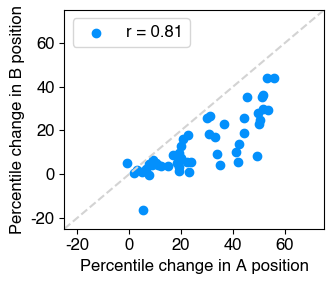

In [8]:
ontarget_expr['pctl_change_a'] = ontarget_expr.target_a_pctl - ontarget_expr.NTC_pctl
ontarget_expr['pctl_change_b'] = ontarget_expr.target_b_pctl - ontarget_expr.NTC_pctl
plt.figure(figsize = (3.5,3))
plt.scatter(ontarget_expr.pctl_change_a, ontarget_expr.pctl_change_b, label = f"r = {np.corrcoef(ontarget_expr.pctl_change_a.astype(np.float64), ontarget_expr.pctl_change_b.astype(np.float64))[0,1]:.2f}", color = '#0390fc')
plt.axline([0,0], slope = 1, linestyle = 'dashed', color = 'lightgrey')
plt.xlim(-25,75)
plt.ylim(-25,75)
plt.xlabel("Percentile change in A position")
plt.ylabel("Percentile change in B position")
plt.legend()
plt.tight_layout()
plt.savefig('2b_ont_ab.pdf')
plt.show()

### 2b energy distance doubles vs singles

In [3]:
from sklearn.preprocessing import normalize
np.bool = bool # this fixes a dcor bug for estimation_stat = 'U'
from dcor import energy_distance
from dcor.homogeneity import energy_test
from scipy.stats import false_discovery_control
import warnings

gex = sc.read("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex_raw.h5ad")

df_pca = pd.DataFrame(normalize(gex.obsm['X_pca']), index = gex.obs_names).join(gex.obs.guide_target)
ntc_pca = df_pca.query("guide_target == 'NTC'").drop(columns='guide_target').sample(n=200, random_state=42).to_numpy()
guides = [g for g in gex.obs.guide_target.value_counts().to_frame('ncells').query("ncells >= 20").index if g != 'NTC']
df_energy = pd.DataFrame(index = guides, columns = ['distance_pca', 'p_pca'])

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for g in tqdm(guides):
        tgt_pca = df_pca.query("guide_target == @g").drop(columns='guide_target').to_numpy()
        df_energy.loc[g, 'distance_pca'] = energy_distance(ntc_pca, tgt_pca, exponent=2, estimation_stat = 'U')

    df_energy = df_energy.join(gex.obs.guide_target.value_counts().to_frame('ncells').ncells)
    df_energy['is_single'] = df_energy.index.map(lambda i: '_' not in i)

plt.figure(figsize = (3.5, 3))
df_energy['is_single_plot'] = df_energy.is_single.map({True: 'Single', False: 'Double'})
ax = sns.boxplot(df_energy, x = 'is_single_plot', y = 'distance_pca', hue = 'is_single', width = 0.75, palette = ['#dddddd', '#0390fc'][::-1], linewidth = 0.5, whiskerprops={'linewidth': 1, 'color': '#444444'}, capprops={'linewidth': 1}, medianprops={'linewidth': 2, 'color': '#444444'}, legend = None)
for i, line in enumerate(ax.lines):
    if i % 6 in [2, 3]: 
        x_data = line.get_xdata()
        mid = (x_data[0] + x_data[1]) / 2
        cap_span = 0.05 
        line.set_xdata([mid - cap_span, mid + cap_span])
plt.ylabel("Energy distance")
plt.xlabel("Perturbations")
plt.tight_layout()
plt.ylim(-0.1, 1.65)
plt.savefig("plots/2c_v1_energy.pdf")
plt.show()

In [10]:
gex.obs.query("guide_target != 'NTC' and not guide_target.str.contains('_')").guide_target.value_counts().to_frame().query("count > 0")['count'].median()

np.float64(474.5)

In [17]:
gex.obs.query("guide_target != 'NTC' and guide_target.str.contains('_')").guide_target.value_counts().to_frame().query("count > 0")['count'].median()

np.float64(171.0)

In [ ]:
from scipy.stats import mannwhitneyu
df_energy['distance_pca'] = df_energy.distance_pca.astype(np.float64)
mannwhitneyu(df_energy.query("is_single").distance_pca, df_energy.query("not is_single").distance_pca, alternative = 'less')

### 2d neo/syn split clustermap

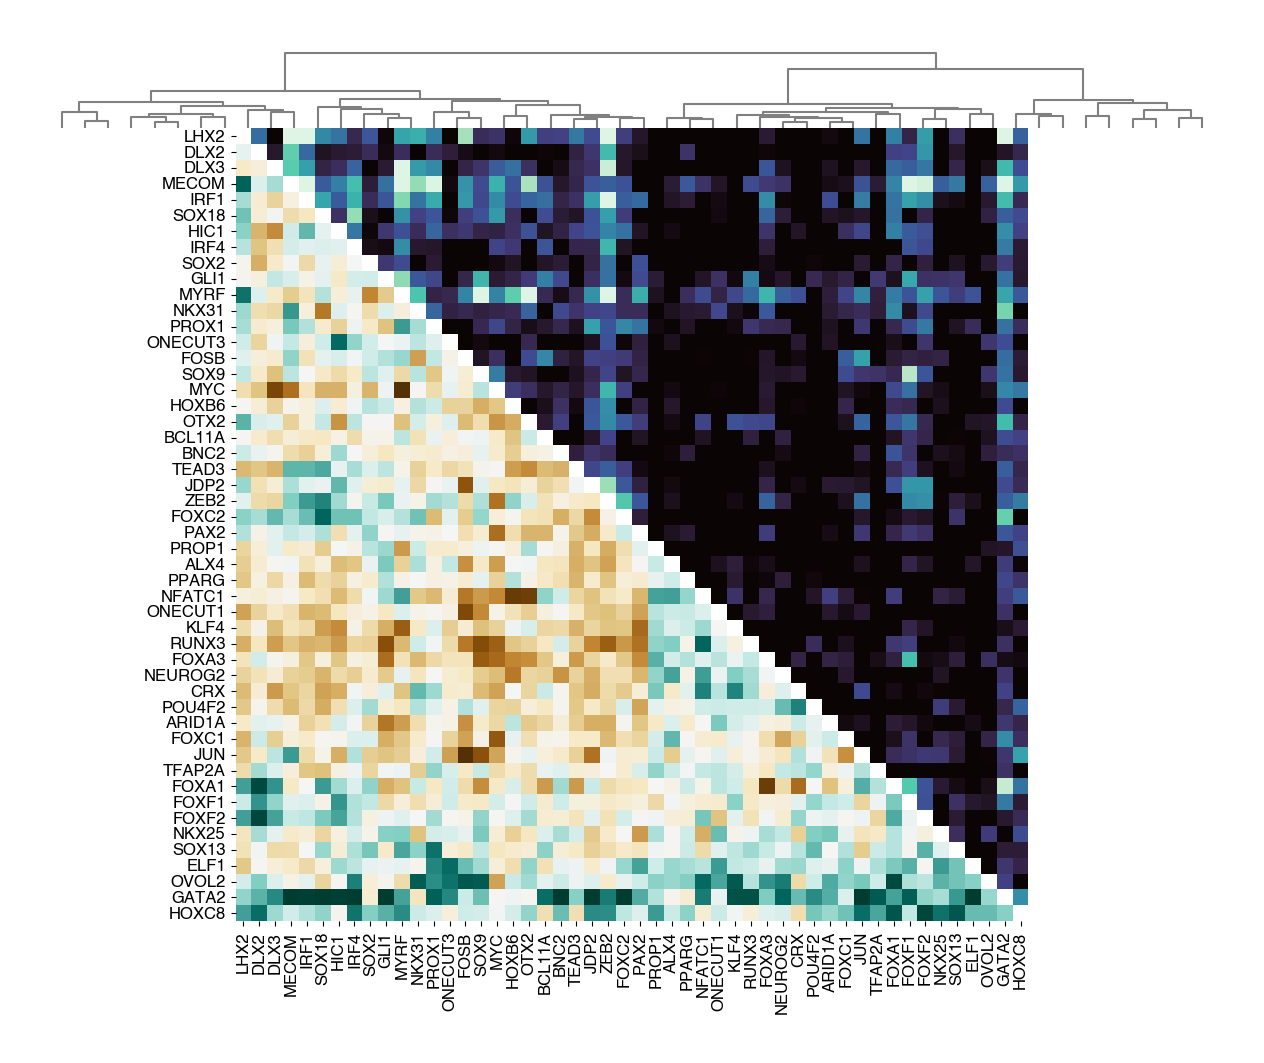

In [ ]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram

df_doubles = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/scvi_direct_emb/260821_scvi_direct_geometry.csv").rename(columns = {'condition': 'guide_target'})

def build_matrix(df, value_col):
    tmp = df[['guide_target', value_col]].copy()
    tmp[['a','b']] = tmp.guide_target.str.split('_', expand=True)
    mat = tmp.pivot(index='a', columns='b', values=value_col)
    mat = mat.combine_first(mat.T)

    tfs = sorted(set(mat.index).union(mat.columns))
    mat = mat.reindex(index=tfs, columns=tfs)

    np.fill_diagonal(mat.values, 0)
    mat = mat.fillna(0)

    return mat

mat_syn = build_matrix(df_doubles.reset_index(), 'r_syn')
mat_neo = build_matrix(df_doubles.reset_index(), 'r_neo')

dist = pdist(mat_syn.values, metric='cosine')
Z = linkage(dist, method="ward")
order = leaves_list(Z)

mat_syn_re = mat_syn.iloc[order, order]
mat_neo_re = mat_neo.iloc[order, order]

mask_upper = np.triu(np.ones_like(mat_syn_re, dtype=bool), k=0)
mask_lower = np.tril(np.ones_like(mat_syn_re, dtype=bool), k=0)

fig = plt.figure(figsize=(12,10))

gs = fig.add_gridspec(
    2, 1,
    height_ratios=(0.5,5),
    hspace=0.0
)

ax_dendro_col = fig.add_subplot(gs[0])
ax_heat = fig.add_subplot(gs[1])

# top dendrogram
dendrogram(
    Z,
    ax=ax_dendro_col,
    no_labels=False,
    color_threshold=0,
    above_threshold_color='grey'
)
ax_dendro_col.axis("off")

sns.heatmap(
    mat_syn_re,
    mask=mask_upper,
    cmap="BrBG_r",
    square=True,
    center=0,
    vmax=3,
    vmin=-3,
    cbar=False,
    cbar_kws={"shrink": .6, "label": "r_syn"},
    ax=ax_heat
)

sns.heatmap(
    mat_neo_re,
    mask=mask_lower,
    cmap='mako',
    square=True,
    vmin = 0,
    vmax=np.percentile(df_doubles.r_neo, 99),
    cbar=False,
    cbar_kws={"shrink": .6, "label": "r_neo"},
    ax=ax_heat,
    xticklabels=1,
    yticklabels=1
)

ax_heat.set_xticklabels(mat_syn_re.columns, rotation=90)
ax_heat.set_yticklabels(mat_syn_re.index, rotation=0)

plt.tight_layout()
# plt.savefig('plots/2e_v5_neo_syn_cluster.pdf')
plt.show()

### 2e linear model heatmap examples

In [ ]:
gex = sc.read("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex_raw.h5ad")
targets = set([t.split("_")[0] for t in gex.obs.target_a.unique() if not pd.isna(t)])
meanpop = gex.to_df().join(gex.obs.guide_target).groupby('guide_target').mean().drop("NTC", axis = 0)
meanpop_fit = meanpop.filter(items = gex.var.query("mean_counts >= 0.25 and index not in @targets").index)

/tmp/ipykernel_239588/2148109025.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [ ]:
from dcor import distance_correlation, partial_distance_correlation
from sklearn.metrics import r2_score
import statsmodels.api as sm

def fit_interaction_model(double):
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        first, second = double.split('_')
        singles_expr = meanpop_fit.loc[[first, second], :].T.values
        first_expr = meanpop_fit.loc[first, :].values.reshape(-1, 1)
        second_expr = meanpop_fit.loc[second, :].values.reshape(-1, 1)
        double_expr = meanpop_fit.loc[double, :].values.reshape(-1, 1)

        model = sm.RLM(double_expr.ravel(), singles_expr, M = sm.robust.norms.TukeyBiweight())
        results = model.fit()
        y_hat = results.fittedvalues

        out = {}
        out['dcor'] = distance_correlation(singles_expr, double_expr)
        out['dcor_singles'] = distance_correlation(first_expr, second_expr)
        out['dcor_model'] = distance_correlation(y_hat.reshape(-1,1), double_expr)
        out['corr_first'] = np.corrcoef(first_expr.flatten(), double_expr.flatten())[0,1]
        out['corr_second'] = np.corrcoef(second_expr.flatten(), double_expr.flatten())[0,1]
        out['corr_sum'] = np.corrcoef((first_expr + second_expr).flatten(), double_expr.flatten())[0,1]
        out['corr_fit'] = np.corrcoef(y_hat.flatten(), double_expr.flatten())[0,1]
        out['corr_first_second'] = pd.Series(first_expr.flatten()).corr(pd.Series(second_expr.flatten()), method='spearman')
        out['r2_score'] = r2_score(double_expr.flatten(), y_hat.flatten())
        weighted_sq_error = results.weights * (results.resid ** 2)
        out['neo_score'] = np.sqrt(np.sum(weighted_sq_error))
        out['name'] = double
        out['rlm_coef_first'] = results.params[0]
        out['rlm_coef_second'] = results.params[1]

        return out

In [ ]:
from joblib import Parallel, delayed

doubles = [i for i in meanpop_fit.index if '_' in i]
results = Parallel(n_jobs=8)(delayed(fit_interaction_model)(double) for double in doubles)
df_results = pd.DataFrame(results).set_index('name').join(gex.obs.guide_target.value_counts().to_frame('ncells'))

In [ ]:
df_results.to_csv("intermediate_files/linear_model_statistics.csv")

In [ ]:
ncells = gex.obs.guide_target.value_counts().to_frame()
ncells.index = ncells.index.map(lambda i: i.replace('_NTC', "").replace('NTC_', ''))
ncells.columns = ['n_cells']

def plot_double(double, results = df_results, meanpop = meanpop_fit, n_genes=100):
    
    # Get singles and coefficients
    result = results.loc[double]
    single1, single2 = double.split('_')
    coef1, coef2 = result['rlm_coef_first'], result['rlm_coef_second']

    # Extract data and select top variance genes
    data = meanpop.loc[[single1, single2, double]]
    top_genes = data.var(axis=0).nlargest(n_genes).index
    
    # Create linear approximation
    linear_approx = coef1 * meanpop.loc[single1][top_genes] + coef2 * meanpop.loc[single2][top_genes]
    
    # Combine all rows
    full_data = pd.concat([data[top_genes], pd.DataFrame(linear_approx).T])
    double_cells = ncells.loc[double, 'n_cells']
    single1_cells = ncells.loc[single1, 'n_cells']
    single2_cells = ncells.loc[single2, 'n_cells']
    full_data.index = [f"{single1} ({single1_cells})", f"{single2} ({single2_cells})", f"{double} ({double_cells})", f"Linear (c1={coef1:.2f}, c2={coef2:.2f})"]

    # Plot clustermap
    return sns.clustermap(
        full_data, 
        cmap="RdBu_r", 
        center=0,
        vmax = 1,
        vmin = -1,
        row_cluster=False,
        robust=True,
        figsize=(10, 2.5),
        xticklabels = 0
    )

In [ ]:
df_results['dominance'] = np.log10(np.abs(df_results.rlm_coef_first) / np.abs(df_results.rlm_coef_second))
df_results['equality'] = df_results.apply(lambda df: np.minimum(df.corr_first, df.corr_second) / np.maximum(df.corr_first, df.corr_second), axis = 1)
df_results['norm'] = np.sqrt(df_results.rlm_coef_first**2 + df_results.rlm_coef_second**2)

2026-08-21 14:24:47 - INFO - maxp pruned
2026-08-21 14:24:47 - INFO - cmap pruned
2026-08-21 14:24:47 - INFO - post pruned
2026-08-21 14:24:47 - INFO - FFTM dropped
2026-08-21 14:24:47 - INFO - GPOS pruned
2026-08-21 14:24:47 - INFO - GSUB pruned
2026-08-21 14:24:47 - INFO - glyf pruned
2026-08-21 14:24:47 - INFO - Added gid0 to subset
2026-08-21 14:24:47 - INFO - Added first four glyphs to subset
2026-08-21 14:24:47 - INFO - Closing glyph list over 'GSUB': 33 glyphs before
2026-08-21 14:24:47 - INFO - Glyph names: ['.notdef', '.null', 'C', 'E', 'J', 'L', 'M', 'N', 'O', 'U', 'a', 'c', 'comma', 'e', 'eight', 'equal', 'five', 'hyphen', 'i', 'n', 'nonmarkingreturn', 'one', 'parenleft', 'parenright', 'period', 'r', 'six', 'space', 'three', 'two', 'underscore', 'uni0008', 'zero']
2026-08-21 14:24:47 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 13, 14, 17, 18, 19, 21, 22, 23, 24, 26, 27, 29, 34, 40, 42, 47, 49, 50, 51, 52, 58, 68, 70, 72, 74, 78, 83, 87]
2026-08-21 14:24:47 - INFO - Closed glyph li

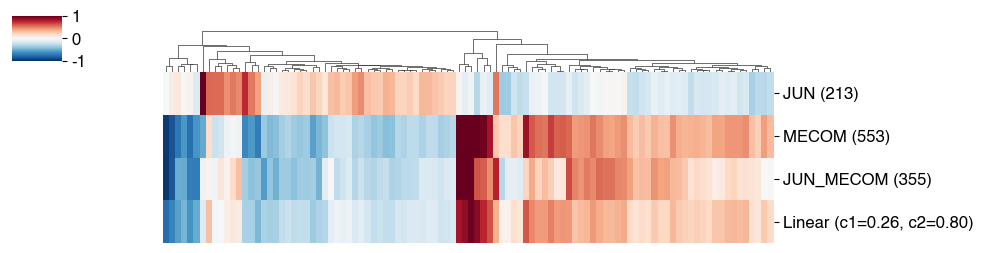

In [ ]:
# epistatic

plot_double('JUN_MECOM')
plt.savefig('plots/2f_v4_jun_mecom.pdf')

2026-08-21 14:24:50 - INFO - maxp pruned
2026-08-21 14:24:50 - INFO - cmap pruned
2026-08-21 14:24:50 - INFO - post pruned
2026-08-21 14:24:50 - INFO - FFTM dropped
2026-08-21 14:24:50 - INFO - GPOS pruned
2026-08-21 14:24:50 - INFO - GSUB pruned
2026-08-21 14:24:50 - INFO - glyf pruned
2026-08-21 14:24:50 - INFO - Added gid0 to subset
2026-08-21 14:24:50 - INFO - Added first four glyphs to subset
2026-08-21 14:24:50 - INFO - Closing glyph list over 'GSUB': 35 glyphs before
2026-08-21 14:24:50 - INFO - Glyph names: ['.notdef', '.null', 'A', 'F', 'L', 'M', 'O', 'R', 'X', 'Y', 'a', 'c', 'comma', 'e', 'equal', 'five', 'four', 'hyphen', 'i', 'n', 'nine', 'nonmarkingreturn', 'one', 'parenleft', 'parenright', 'period', 'r', 'seven', 'six', 'space', 'three', 'two', 'underscore', 'uni0008', 'zero']
2026-08-21 14:24:50 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 13, 14, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 30, 34, 38, 43, 49, 50, 52, 55, 61, 62, 68, 70, 72, 74, 78, 83, 87]
2026-08-21 14:24:50 

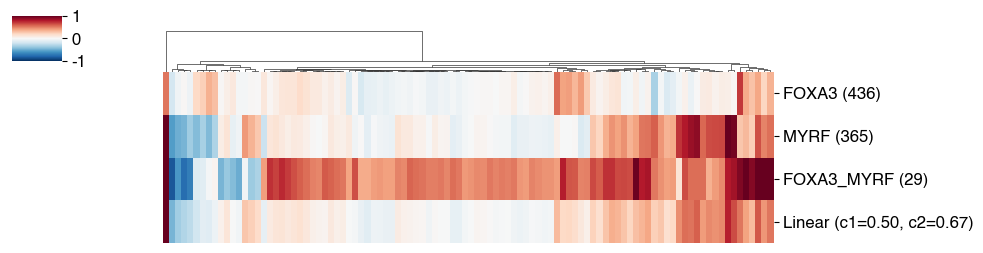

In [ ]:
# neomorphic

plot_double('FOXA3_MYRF')
plt.savefig('plots/2f_v4_FOXA3_MYRF.pdf')

### 2f circos strip plot

In [29]:
df_doubles = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/scvi_direct_emb/260821_scvi_direct_geometry.csv").rename(columns = {'condition': 'guide_target'})
gex = sc.read('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex.h5ad')

sctfs_exact = pd.read_csv("/data1/normantm/eli/T7/202412_multiome_TFs/analysis/intermediate_files/sc_motif_scores_differential.csv", index_col = 0)
chromvar_exact = pd.read_csv("/data1/normantm/eli/scprinter/RPE1_jaspar26_chromvar_motifs_differential.csv").query("q < 0.1") # jaspar26 by guide
chromvar_exact['gene'] = chromvar_exact['gene'].str.split(".").str[-1]
df_scores = pd.concat([sctfs_exact, chromvar_exact], axis=0)
mapper = {'Alx4': 'ALX4', 'Crx': 'CRX', 'Dlx2': 'DLX2', 'Dlx3': 'DLX3', 'Irf1': 'IRF1', 'Hic1': 'HIC1', 'Nfatc1': 'NFATC1', 'Foxf1': 'FOXF1', 'Jun': 'JUN', 'Nkx3-1': 'NKX31', 'NKX2-5': 'NKX25', 'Gli1': 'GLI1', 'Fosb': 'FOSB', 'Mecom': 'MECOM'}
df_scores['corrected_motif'] = df_scores['gene'].map(lambda g: mapper.get(g, g))
df_scores = df_scores.sort_values('q').drop_duplicates(['corrected_motif', 'guide_target'], keep='first')

def get_priming_score(df):

    first, second = df.guide_target.split('_')
    primed_ab, primed_ba = df_scores.query("corrected_motif == @first and guide_target == @second"), df_scores.query("corrected_motif == @second and guide_target == @first")

    z_ab = primed_ab.z.item() if not primed_ab.empty else None
    z_ba = primed_ba.z.item() if not primed_ba.empty else None

    return z_ab, z_ba

df_doubles[['primed_ab', 'primed_ba']] = df_doubles.progress_apply(get_priming_score, axis = 1, result_type = 'expand')
df_doubles['is_primed'] = df_doubles.apply(lambda df: df.primed_ab > 0 or df.primed_ba > 0, axis = 1)
is_homolog = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/is_homolog.csv", usecols = [0,1], index_col = 0).query("is_homolog == True").index.tolist()
df_doubles['is_primed_no_homolog'] = df_doubles.apply(lambda df: df.is_primed and df.guide_target not in is_homolog, axis = 1)

degs = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_degs.csv")
tgts = degs.guide_target.unique()
def get_new_genes(guide_target):

    a, b = guide_target.split("_")
    a_genes, b_genes = degs.query('guide_target == @a and z > 0').gene.unique(), degs.query('guide_target == @b and z > 0').gene.unique()
    return degs.query(f"guide_target == '{guide_target}' and not gene.isin(@a_genes) and not gene.isin(@b_genes)")

deg_singles = degs.query("not guide_target.str.contains('_') and gene in @tgts").copy()
deg_singles['interaction'] = deg_singles.apply(lambda df: df.gene + "_" + df.guide_target if df.gene < df.guide_target else df.guide_target + "_" + df.gene, axis=1)
deg_singles = deg_singles.set_index('interaction').join(df_doubles.r_neo)
exclude_ab = deg_singles.query("gene in @tgts and gene != guide_target and not guide_target.str.contains('_') and z >= 0.1").index
df_doubles = df_doubles.set_index('guide_target')
df_doubles.loc[exclude_ab, 'is_primed_no_homolog'] = False

100%|██████████| 1225/1225 [00:08<00:00, 139.11it/s]


In [30]:
df_doubles['bidirectional'] = df_doubles.apply(lambda df: df.primed_ab > 0 and df.primed_ba > 0 and df.is_primed_no_homolog, axis=1)
print(df_doubles.bidirectional.sum())
df_doubles.sort_values('r_neo', ascending=False).head(20)

57


,r_mixed,r_additive,sim_additive,sim_a,sim_b,gamma,dominant_tgt,r_syn,r_neo,primed_ab,primed_ba,is_primed,is_primed_no_homolog,bidirectional
guide_target,,,,,,,,,,,,,,
LHX2_ZEB2,5.064043,7.968313,0.339363,0.317794,0.167363,0.947522,LHX2,-0.241410,6.448323,0.318909,0.168997,True,True,True
GATA2_MECOM,2.884639,9.684602,0.175416,0.122811,0.136304,0.977617,MECOM,-3.563551,5.742360,-0.296600,0.661651,True,True,False
LHX2_MECOM,2.642515,7.639948,0.154223,-0.002851,0.216524,0.712095,MECOM,-2.444306,5.574971,0.209086,-0.142113,True,True,False
MYRF_ZEB2,5.278575,8.154614,0.511756,0.371668,0.324149,0.999789,MYRF,-0.150920,5.498671,NaN,NaN,False,False,False
IRF1_ZEB2,3.527075,7.932992,0.305728,0.207193,0.228769,0.999854,ZEB2,-1.754860,5.372311,0.175905,NaN,True,True,False
IRF1_MECOM,5.564265,7.972309,0.568941,0.324295,0.507061,0.975952,MECOM,0.256152,4.810386,0.324588,NaN,True,True,False
MECOM_MYRF,6.744740,8.556838,0.541711,0.379670,0.408667,0.999846,MYRF,1.047436,4.739772,0.711669,NaN,True,True,False
IRF1_LHX2,4.642298,8.300323,0.381550,0.286359,0.297295,0.999916,LHX2,-0.884214,4.717456,-0.139206,NaN,False,False,False
MYRF_SOX9,6.198840,8.047517,0.579990,0.292397,0.505989,0.956541,SOX9,0.840652,4.534818,NaN,0.745951,True,True,False


In [ ]:
df_doubles.to_csv("intermediate_files/scvi_direct_global_interaction_metrics.csv")

In [ ]:
df_doubles = pd.read_csv("intermediate_files/scvi_direct_global_interaction_metrics.csv", index_col = 0)

In [3]:
expt = mo.MultiomeExperiment.load('/data1/normantm/multiome_collab/RPE1/intermediate_files/RPE1_multiomeTFs.pkl')
tgts = expt.gex.obs.guide_target.value_counts().to_frame('ncells').query("ncells >= 20")

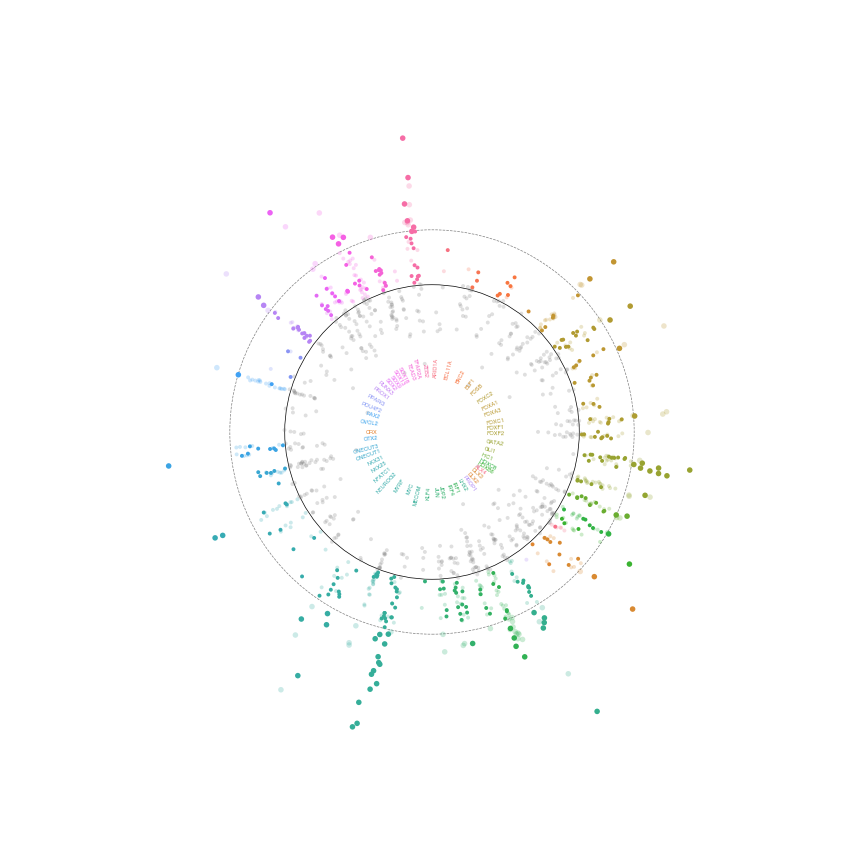

In [4]:
from matplotlib.colors import to_rgba
from pycirclize import Circos

df = df_doubles.copy()
df_primed = df_doubles[['primed_ab', 'primed_ba', 'is_primed_no_homolog']].copy().reset_index()
df_primed[['a','b']] = df_primed.guide_target.str.split('_', expand = True)
df_primed['connection_score'] = df_primed.apply(lambda df: np.nan if not df.is_primed_no_homolog else np.nanmax([df.primed_ab, df.primed_ba]), axis = 1)
df_primed['direction'] = df_primed.apply(
    lambda df:
        np.nan if not df.is_primed_no_homolog else
        'ab' if pd.isna(df.primed_ba) else
        'ba' if pd.isna(df.primed_ab) else
        'ab' if df.primed_ab > df.primed_ba else
        'ba',
    axis=1,
)

singles = pd.read_csv('/data1/normantm/eli/T7/rpe1_paper/intermediate_files/circos_singles.csv')

mtx = pd.DataFrame(0.0, index = singles.sort_values('group').guide_target, columns = singles.sort_values('group').guide_target)
for idx, row in df_primed.iterrows():
    if np.isnan(row.connection_score):
        continue
    if row.direction == 'ab':
        mtx.loc[row.a, row.b] += row.connection_score
    elif row.direction == 'ba':
        mtx.loc[row.b, row.a] += row.connection_score

mtx = np.clip(mtx, 0, 2)
gex = sc.read('/data1/normantm/multiome_collab/RPE1/RPE1_multiome_gex.h5ad')
tgts = gex.obs.guide_target.value_counts().to_frame('ncells').query("ncells >= 20")
palette = sns.color_palette("husl", len(tgts)).as_hex()
color_mapping = dict(zip(tgts.sort_index().index.tolist(), palette))
gene_order = singles.sort_values('group').guide_target

singles_grouped = pd.read_csv("/data1/normantm/eli/T7/rpe1_paper/intermediate_files/circos_singles_grouped.csv")
spaces = singles_grouped.space.tolist()
spaces = [s / 2 if s == 1 else s for s in spaces]
spaces = list(map(lambda x: x/2, spaces))

from pycirclize import Circos
circos_chord = Circos.chord_diagram(
    mtx,
    space=spaces,
    cmap=color_mapping,
)

circos_chord = Circos.chord_diagram(mtx, space=spaces, cmap=color_mapping)
sector_sizes = {s.name: s.size for s in circos_chord.sectors}
circos = Circos(sector_sizes, space=spaces)

y_min, y_max = df['r_neo'].min(), df['r_neo'].max()
pad = 0.05 * (y_max - y_min)
y_min, y_max = y_min - pad, y_max + pad

rng = np.random.default_rng(42)

r_neo_90 = np.percentile(df['r_neo'], 90)
for sector in circos.sectors:
    color = color_mapping.get(sector.name, "grey")
    sector.axis(fc="none", ec="none")
    sector.text(sector.name, r=15, size=4, weight="bold", color=color,
                adjust_rotation=True, orientation="vertical")

    track = sector.add_track((10, 95), r_pad_ratio=0.05)
    track.axis(ec="none")

    sub = df.loc[df['dominant_tgt'] == sector.name]
    if len(sub) == 0:
        continue

    margin = 0.25 * sector.size

    below_zero = sub['r_neo'] < 0
    above_p90 = sub['r_neo'] > r_neo_90

    groups = [
        (sub[below_zero], "grey", 0.25, 8),
        (sub[~below_zero & sub['is_primed_no_homolog'] & above_p90], color, 1.0, 16),
        (sub[~below_zero & sub['is_primed_no_homolog'] & ~above_p90], color, 1.0, 8),
        (sub[~below_zero & ~sub['is_primed_no_homolog'] & above_p90], color, 0.25, 16),
        (sub[~below_zero & ~sub['is_primed_no_homolog'] & ~above_p90], color, 0.25, 8),
    ]
    above_p90_group = {1, 3}  # indices of the two above-p90 groups in `groups`

    for i, (group, c, alpha, size) in enumerate(groups):
        if len(group) == 0:
            continue
        x = rng.uniform(margin, sector.size - margin, size=len(group))
        track.scatter(
            x, group['r_neo'].values,
            vmin=y_min, vmax=y_max,
            color=c, s=size, ec="none", alpha=alpha,
        )

r_frac_zero = (0 - y_min) / (y_max - y_min)
r_zero = 10 + r_frac_zero * (95 - 10)

r_frac_90 = (r_neo_90 - y_min) / (y_max - y_min)
r_90 = 10 + r_frac_90 * (95 - 10)

fig = circos.plotfig(figsize=(8, 8))
for ax in fig.axes:
    for patch in ax.patches:
        patch.set_zorder(0)
    for collection in ax.collections:
        collection.set_zorder(2)

circos.ax.add_patch(
    plt.Circle((0, 0), r_zero, transform=circos.ax.transData._b,
               fill=False, ec="black", lw=0.5, alpha=1)
)
circos.ax.add_patch(
    plt.Circle((0, 0), r_90, transform=circos.ax.transData._b,
               fill=False, ec="black", ls="--", lw=0.5, alpha=0.5)
)

plt.tight_layout()
# plt.savefig('plots/2d_circos_scvi_direct_rneo.pdf', dpi=300)
plt.show()

In [8]:
from scipy.stats import fisher_exact

r_neo_90 = df_doubles['r_neo'].quantile(0.9)
above = df_doubles['r_neo'] > r_neo_90
table = pd.crosstab(above, df_doubles['is_primed_no_homolog'])
odds_ratio, p_value = fisher_exact(table, alternative='greater')
print(f"OR = {odds_ratio:.2f}, p = {p_value:.2e}")
print(table.div(table.sum(axis=1), axis=0))

OR = 1.48, p = 2.37e-02
is_primed_no_homolog     False     True 
r_neo                                   
False                 0.569873  0.430127
True                  0.471545  0.528455


In [ ]:
from scipy.stats import ttest_ind, mannwhitneyu, wilcoxon, ttest_rel
print(df_doubles.groupby("is_primed_no_homolog").r_neo.mean())
print(df_doubles.groupby("bidirectional").r_neo.mean())
print(ttest_ind(df_doubles.query("is_primed_no_homolog").r_neo, df_doubles.query("not is_primed_no_homolog").r_neo, equal_var = False, alternative = 'greater'))
print(ttest_ind(df_doubles.query("bidirectional").r_neo, df_doubles.query("not is_primed_no_homolog").r_neo, equal_var = False, alternative = 'greater'))

is_primed_no_homolog
False    0.272343
True     0.435030
Name: r_neo, dtype: float64
bidirectional
False    0.327080
True     0.689113
Name: r_neo, dtype: float64
TtestResult(statistic=np.float64(2.245419774175104), pvalue=np.float64(0.012473589019798064), df=np.float64(1057.2842053727018))
TtestResult(statistic=np.float64(2.159491820024262), pvalue=np.float64(0.017337889042257675), df=np.float64(62.197578655603415))


### 2g neomorphic score distributions

/tmp/ipykernel_3213990/2980732762.py:21: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
2026-09-09 14:07:06 - INFO - maxp pruned
2026-09-09 14:07:06 - INFO - cmap pruned
2026-09-09 14:07:06 - INFO - post pruned
2026-09-09 14:07:06 - INFO - FFTM dropped
2026-09-09 14:07:06 - INFO - GPOS pruned
2026-09-09 14:07:06 - INFO - GSUB pruned
2026-09-09 14:07:06 - INFO - glyf pruned
2026-09-09 14:07:06 - INFO - Added gid0 to subset
2026-09-09 14:07:06 - INFO - Added first four glyphs to subset
2026-09-09 14:07:06 - INFO - Closing glyph list over 'GSUB': 20 glyphs before
2026-09-09 14:07:06 - INFO - Glyph names: ['.notdef', '.null', 'N', 'c', 'e', 'four', 'h', 'hyphen', 'i', 'm', 'nonmarkingreturn', 'o', 'p', 'r', 's', 'six', 'space', 'two', 'uni0008', 'zero']
2026-09-09 14:07:06 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 18, 21, 23, 25, 27, 51, 72, 74, 77, 78, 82, 84, 85, 87, 88]
2026-09-09 14:07:06 - INFO - Closed glyph list over 'GSUB': 20 glyphs after

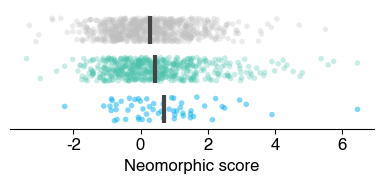

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(4, 2))
df_doubles['primed_bidirectional'] = df_doubles.bidirectional.map(lambda i: 'bidirectional' if i else 'unidirectional')

sns.stripplot(
    data=df_doubles, x='r_neo', y='is_primed_no_homolog',
    orient='h', hue = 'is_primed_no_homolog', palette = ['#bfbfbf', '#4bc2ad', ], alpha=0.3, jitter=0.3,
    size=4, ax=ax, zorder = 0, legend = None
)

sns.pointplot(
    data=df_doubles, x='r_neo', y='is_primed_no_homolog',
    orient='h', color='#444444', linestyle='none',
    markers='|', markersize=20, markeredgewidth=3,
    errorbar=None, ax=ax, zorder = 1
)

sns.stripplot(
    data=df_doubles.query("bidirectional"), x='r_neo', y='primed_bidirectional',
    orient='h', hue = 'primed_bidirectional', palette = ['#00b0f0', '#bfbfbf',], alpha=0.5, jitter=0.3,
    size=4, ax=ax, zorder = 0, legend = None
)

sns.pointplot(
    data=df_doubles.query("bidirectional"), x='r_neo', y='primed_bidirectional',
    orient='h', color='#444444', linestyle='none',
    markers='|', markersize=20, markeredgewidth=3,
    errorbar=None, ax=ax, zorder = 1
)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.xlabel("Neomorphic score")
plt.ylabel("")
plt.yticks([])
plt.tight_layout()
plt.savefig("plots/2g_neomorphic_dist.pdf")
plt.show()